# Formalia:

Please read the [assignment overview page](https://github.com/suneman/socialgraphs2025/wiki/Assignments) carefully before proceeding. This page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

_If you fail to follow these simple instructions, it will negatively impact your grade!_

**Due date and time**: The assignment is due on Tuesday September 30th, 2025 at 23:55. Hand in your IPython notebook file (with extension `.ipynb`) via DTU Learn

# Assignment 1.1: Exploring WS and BA models

This first part draws on the Watts-Stogatz and Barabasi-Albert models from Week 3. You should provide solutions to the exercises with the following titles from **Part 1** 


> *Exercises*: Did you really read the text? Answer the following questions (no calculations needed) in your IPython notebook. 
> 
> * What's the problem with random networks as a model for real-world networks according to the argument in section 3.5 (near the end)?
>   * The range of $\langle k\rangle$ in random networks is quite narrow, with the degree of all nodes falling into this range. Real-world networks usually have outlier nodes, that have degrees much smaller or greater than the average, which random networks don't account for.

> * List the four regimes that characterize random networks as a function of $\langle k \rangle$.
>   * Subcritical: $ 0< \langle k \rangle < 1$
>   * Critical point: $\langle k \rangle=1$
>   * Supercritical regime: $\langle k \rangle>1$
>   * Connected regime: $\langle k \rangle >\ln{N}$
> * According to the book, why is it a problem for random networks (in terms of being a model for real-world networks) that the degree-dependent clustering $C(k)$ decreases as a function of $k$ in real-world networks?
>   * For random networks the clustering is the same for all nodes, as it relies on N and the average degree, whereas $C(k)$ is dependent on the degree of the individual node. 


> *Exercises*: WS edition.
> * First, let's use `networkx` to play around with WS graphs. Use `nx.watts_strogatz_graph` to generate 3 graphs with 500 nodes each, average degree = 4, and rewiring probablity $p = 0, 0.1,$ and  $1$. Calculate the average shortest path length $\langle d \rangle$ for each one. 


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

random.seed(5)

N = 500
k = 4
p1 = 0
p2 = 0.1
p3 = 1

G1 = nx.watts_strogatz_graph(N, k, p1)
G2 = nx.watts_strogatz_graph(N, k, p2)
G3 = nx.watts_strogatz_graph(N, k, p3)

av_d1 = nx.average_shortest_path_length(G1)
av_d2 = nx.average_shortest_path_length(G2)
av_d3 = nx.average_shortest_path_length(G3)

print(f"Average shortest path length for p={p1}: {av_d1}")
print(f"Average shortest path length for p={p2}: {av_d2}")
print(f"Average shortest path length for p={p3}: {av_d3}")

Average shortest path length for p=0: 62.875751503006015
Average shortest path length for p=0.1: 7.687374749498998
Average shortest path length for p=1: 4.715246492985972


> * Describe what happens to the network when $p = 1$.
>      * When $p=1$ the network loses all it's original structure, and becomes a completely random network, as all the nodes are rewired. 
> * Generate a lot of networks with different values of $p$. You will notice that paths are short when $p$ is close to one and they are long when $p = 0$. 


In [2]:
ps = [0,0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
avg_path_lengths = []
for p in ps:
    G = nx.watts_strogatz_graph(N, k, p)
    avg_path_length = nx.average_shortest_path_length(G)
    avg_path_lengths.append(avg_path_length)

avg_path_lengths

[62.875751503006015,
 30.35634468937876,
 7.568304609218437,
 6.008633266533066,
 5.369338677354709,
 5.155519038076152,
 4.946661322645291,
 4.841907815631263,
 4.785394789579159,
 4.809827655310621,
 4.784104208416833,
 4.796336673346693]

> * What's the value of $p$ for which the average shortest path length gets close to the short paths we find in a fully randomized network.
>   * At around $p=0.5$, we reach an average path length of less than 5, which is close to the short paths we find in a fully randomized network. 

> * Let's investigate this behavior in detail. Generate 50 networks with $N = 500$, $\langle k \rangle = 4$, for each of $p = \{0, 0.01, 0.03, 0.05, 0.1, 0.2\}$. Calculate the average of $\langle d \rangle$ as well as the standard deviation over the 50 networks, to create a plot that shows how the path length decreases very quickly with only a little fraction of re-wiring. Use the standard deviation to add [errorbars](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) to the plot. My version of the plot is below (since a picture's worth 1000 words).


In [3]:
N = 500
k = 4
ps = [0, 0.01, 0.03, 0.05, 0.1, 0.2]

means = []
stds = []
    
for p in ps:
    avg_path_lengths = []
    for _ in range(50):  # Average over 50 runs for each p
        G = nx.watts_strogatz_graph(N, k, p)
        avg_path_length = nx.average_shortest_path_length(G)
        avg_path_lengths.append(avg_path_length)
    means.append(np.mean(avg_path_lengths))
    stds.append(np.std(avg_path_lengths))

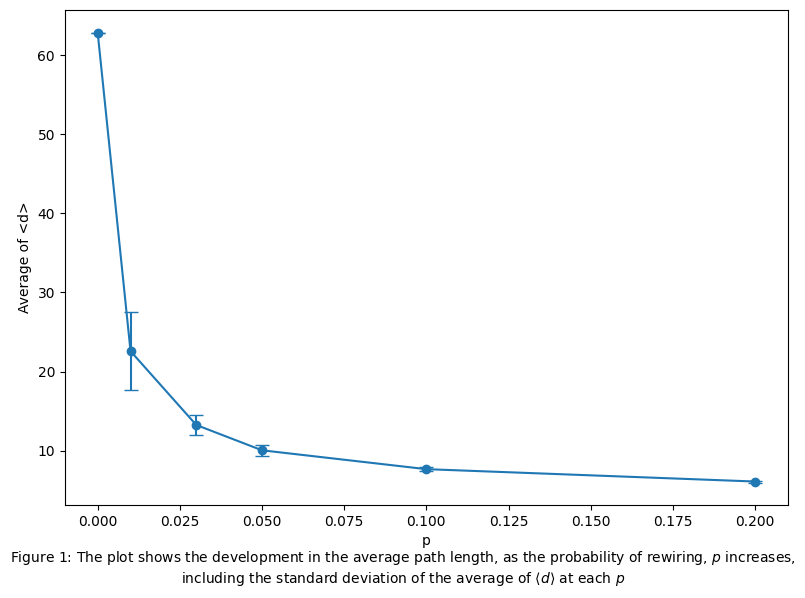

In [4]:
plt.figure(figsize=(8, 6))
plt.errorbar(ps, means, yerr=stds, fmt='o-', capsize=5)
plt.xlabel('p')
plt.ylabel('Average of <d>')
plt.figtext(0.5, 0.02, 'Figure 1: The plot shows the development in the average path length, as the probability of rewiring, $p$ increases,\nincluding the standard deviation of the average of $\\langle d \\rangle$ at each $p$', 
            ha='center', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for caption
plt.show()

And from **Part 2**

* *BA Edition*.
  * **Note**: The second part of this exercise (after the questions to the text) first has you build a BA network step-by-step, but doesn't ask any questions. For that part, I would simply like you to write well-documented code that shows how you build the network. 
>
> First a couple of questions to make sure that you've actually read the text.
> 
> * What are the three slope dependent regimes of complex networks with power-law degree distributions? Briefly describe each one. (You will have to skim chp 4.7 to answer this one).
>   * **Anomalous Regime ($\lambda \leq 2$)**: The number of links connected to the largest hub grows faster than the size of the network. $\langle k \rangle$ diverges as $N \rightarrow \infty$
>   * **Scale-Free Regime ($2 < \lambda <3$)**: The first moment of degree distribution is finite, second and higher diverge. Scale-free networks are ultra small. The largest hub decreases as $k_{max}/N \approx N^{-(\lambda-2)//(\lambda-1)}$
>   * **Random Network Regime ($\lambda > 3$)**: First and second moments are finite. It is difficult to distinguish between scale-free and random networks. The desired scale between $k_{min}$ and $k_{max}$ is $N=\large(\frac{k_{max}}{k_{min}}\large)^{\lambda-1}$
> * What are the three regimes we find in non-linear preferential attachement? (chapter 5) Briefly describe each one.
>   * **Sublinear Regime ($0 < \alpha < 1$)**: The degree distribution follows the stretched exponential, resulting in fewer and smaller hubs than in a scale-free network. As $\alpha \rightarrow 1$ the cutoff length increases and $p_k$ follows a power law over an increasing range of degrees.
>   * **Linear Regime ($\alpha=1$)**: This corresponds to the Barabási-Albert model, hence the degree distribution follows a power law.
>   * **Superlinear Regime ($\alpha > 1$)**: The high-degree nodes are disproportionately attractive. A winner-takes-all dynamics leads to a hub-and-spoke topology. In this configuration the earliest nodes become super hubs and all subsequent nodes link to them. The degree distribution, shown for $\alpha=1.5$ indicates the coexistence of many small nodes with a few super hubs in the vicinity of $k=104$.



In [5]:
## Creating the the BA graph with a single link
G = nx.Graph()
G.add_edge(0,1)

## Creating a function, that adds new nodes, until the graph has N nodes
def preferential_attachment(G, N):
    # Add nodes until we reach N nodes
    while G.number_of_nodes() < N:
        # Create a list of nodes where each node appears as many times as its degree
        degree_list = []
        for node in G.nodes():
            # Append the node to the list as many times as its degree
            degree = G.degree(node)
            degree_list.extend([node] * degree)
        
        # Randomly select a target node from the degree list
        target_node = random.choice(degree_list)
        # Add a new node and connect it to the target node
        new_node = G.number_of_nodes()
        G.add_edge(new_node, target_node)
    
    return G

# Generating the BA graph with one extra node
G3 = preferential_attachment(G, 3)

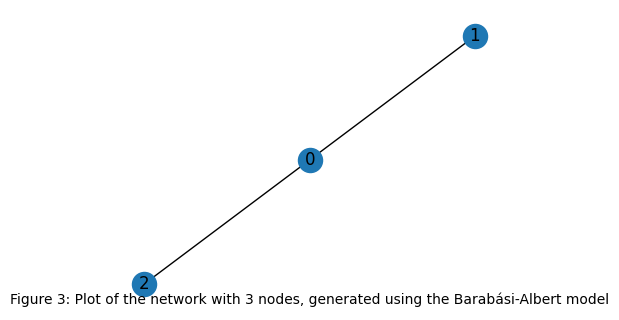

In [6]:
plt.figure(figsize=(4, 3))
nx.draw(G3, with_labels=True)
plt.figtext(0.5, 0.02, 'Figure 3: Plot of the network with 3 nodes, generated using the Barabási-Albert model', 
            ha='center', fontsize=10)
plt.show()

In [7]:
# Generating the BA graph with 100 nodes
G100 = preferential_attachment(G3, 100)

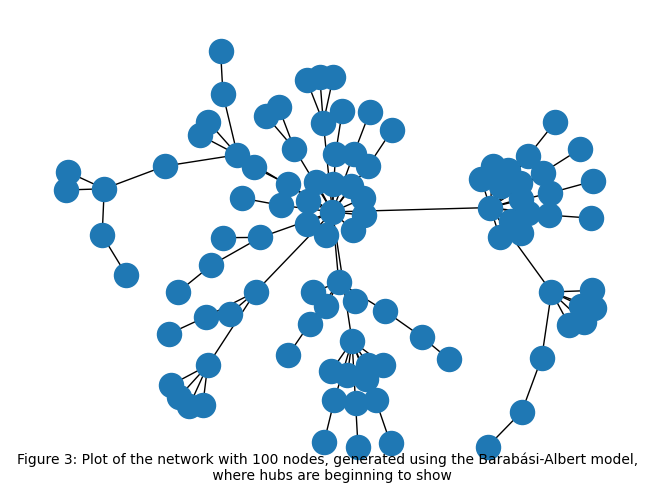

In [8]:
nx.draw(G100, with_labels=False)
plt.figtext(0.5, 0.02, 'Figure 3: Plot of the network with 100 nodes, generated using the Barabási-Albert model, \n where hubs are beginning to show', 
            ha='center', fontsize=10)
plt.show()

In [9]:
# Generating the BA graph with 5000 nodes
G5000 = preferential_attachment(G100, 5000)

> * What's the maximum and minimum degree?
>   * The maximum degree is 181, and the minimum degree is 1

In [10]:
max_degree = max(dict(G5000.degree()).values())
min_degree = min(dict(G5000.degree()).values())

print("Max degree:", max_degree)
print("Min degree:", min_degree)

Max degree: 181
Min degree: 1


> * Now, bin the degree distribution using `numpy.histogram`.

In [11]:
counts, bins = np.histogram(list(dict(G5000.degree()).values()), bins=max_degree)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

> * Plot the distribution. Plot it with both linear and log-log axes.

In [12]:
log_counts = np.log10(counts)
log_bins = np.log10(bin_centers)

C:\Users\sofie\AppData\Local\Temp\ipykernel_34768\435626052.py:1: RuntimeWarning: divide by zero encountered in log10
  log_counts = np.log10(counts)


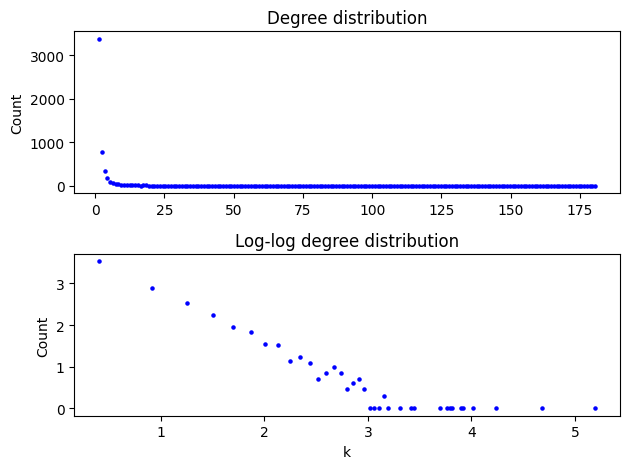

In [13]:
plt.subplot(2,1,1)
plt.scatter(bin_centers, counts, marker="o", color="b",s=5)
plt.ylabel("Count")
plt.title("Degree distribution")

plt.subplot(2,1,2)
plt.scatter(np.log(bin_centers), log_counts, marker="o", color="b", s=5)
plt.xlabel("k")
plt.ylabel("Count")
plt.title("Log-log degree distribution")

plt.tight_layout()
plt.show()

It is hard to see any correlation between counts and the degree distribution in the linear plot, however, in the log-log plot, the distribution has a linear correlation, which fits with the power law distribution of a real network (as seen in image 4.2 in the book). 

# Assignment 1.2: Stats and visualization of the Rock Music Network

This second part requires you to have built the network of Rock Musicians as described in the exercises for Week 4. You should complete the following exercise from **Part 2**.

* *Explain your process in words*

# Documentation of Crawling the Network

## Step-by-Step Process

1. **Collecting the performer list**
   We started with a txt file with the raw wiki data from the web site `rock_performers_clean.txt` and used this to construct a CSV file `mainstream_rock_artists.csv` containing all the performers to include as nodes in the network.

2. **Downloading Wikipedia pages**
   For each performer, we retrieved the raw wikitext from the Wikipedia API. This gave the cleanest version of each article. Each page was saved locally in the folder `wikitext_pages/`, one file per performer.

3. **Extracting links**
   We used a regular expression to capture internal wiki links of the form `[[Target]]` or `[[Target|Display]]`.

   * If a link pointed to another performer from our list we kept it.
   * If the link pointed to anything else (albums, places, categories, etc.), we discarded it.

4. **Building the graph**
   Using NetworkX, we built a directed graph (`DiGraph`). Each performer became a node. For every direct link between performer A’s page and performer B’s page we added a directed edge from A to B.

5. **Adding node attributes**
   While processing each page we counted the number of words (using a regex tokenizer) and stored this as the attribute `content_length` on each node.

6. **Cleaning the graph**
   After building the full network, we removd isolated nodes (performers with no in- or out-edges). Finally, we extracted the largest weakly connected component (LCC) to ensure that the graph was usable for visualization and further analysis.


## Most Difficult Part

The most challenging aspect was handling **naming mismatches** between the performer list and the actual Wikipedia pages.

* Wikipedia titles sometimes use slashes (e.g. `AC/DC`) or punctuation (`The_B-52's`), but when saved as files these had to be normalized (`ACDC`, `The_B-52s`).
* Some performers also redirect to slightly different pages (e.g. `Jet_(Australian_band)` → `Jet_(band)`) which meant we had to normalize and rename multiple variants to the same performer.

Without aligning these names some edges would be lost and some nodes would appear as disconnected, even if they actually had links in Wikipedia.



* *Simple network statistics and analysis*.

  * **Note related to this and the following exercise**. It is nice to have the dataset underlying the statistics and visualization available when we grade. Therefore, I recommend that you create a small *network dataset*, which is simply your graph stored in some format that you like (since it's only a few hundred nodes and a few thousand edges, it won't take up a lot of space). You can then place that network one of your group members' GitHub account (or some other server that's available online) and have your Jupyter Notebook fetch that dataset when it runs. (It's OK to use an LLM for help with setting this up, if it seems difficult). 

In [14]:
RAW = "https://raw.githubusercontent.com/mathiaskrois/02805-Social-graphs-and-interactions---Fall-2025/main/data"

nodes_url = f"{RAW}/rock_nodes.csv"
edges_url = f"{RAW}/rock_edges.csv"

nodes = pd.read_csv(nodes_url)
edges = pd.read_csv(edges_url)

# Reconstruct the directed graph
G = nx.DiGraph()
G.add_nodes_from(nodes["node"])
nx.set_node_attributes(
    G, {row.node: int(row.content_length) for _, row in nodes.iterrows()},
    name="content_length"
)
G.add_edges_from(edges[["source","target"]].itertuples(index=False, name=None))

print("Loaded:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

Loaded: 485 nodes, 8074 edges


*Exercise*: Simple network statistics and analysis

> * What is the number of nodes in the network? 
> * More importantly, what is the number of links? (Chat with a fellow student or a TA to make sure you're in the right ball-park)


In [15]:
# Number of nodes and edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 485
Number of edges: 8074


> * Plot the in and out-degree distributions for the entire network. What do you observe? Can you explain why the in-degree distribution is different from the out-degree distribution?

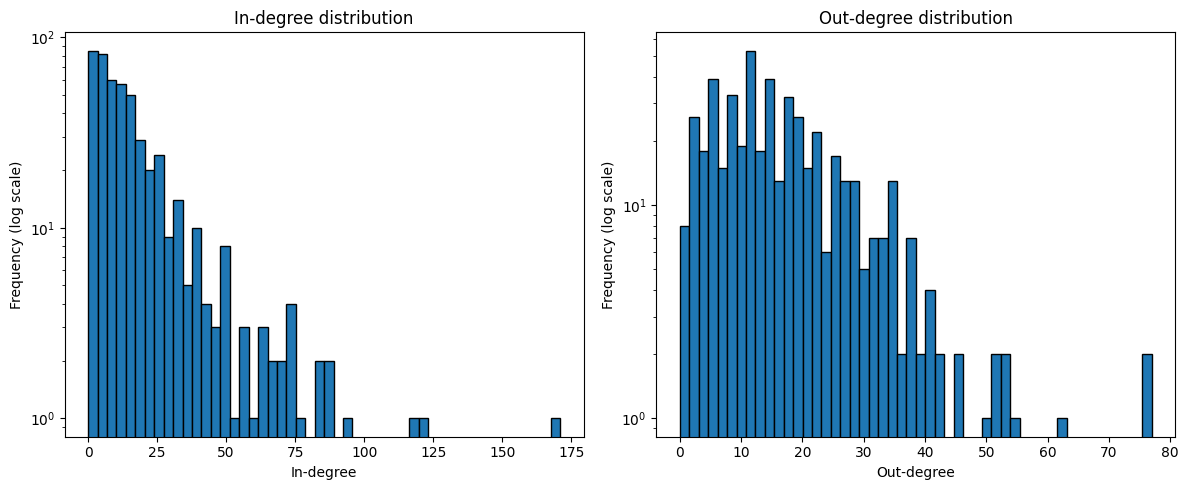

In [16]:
# Collect degree sequences
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(in_degrees, bins=50, log=True, edgecolor="black")
plt.xlabel("In-degree")
plt.ylabel("Frequency (log scale)")
plt.title("In-degree distribution")

plt.subplot(1,2,2)
plt.hist(out_degrees, bins=50, log=True, edgecolor="black")
plt.xlabel("Out-degree")
plt.ylabel("Frequency (log scale)")
plt.title("Out-degree distribution")

plt.tight_layout()
plt.show()

**In-degree distribution**<br>
  Most performers receive very few incoming links but a few of very popular acts receive a very large number (long right tail). This is why the distribution looks heavy-tailed and skewed.
  
**Out-degree distribution**<br>
  The out-degree is more evenly spread and doesn’t have such extreme values. That’s because each Wikipedia page is only written once, and there’s a practical limit to how many other bands an editor will include as links.

**Why the difference?**<br>
* In-degree reflects how many other pages point to a performer. Since many bands might reference a very famous act (e.g., as an influence or collaborator), some performers accumulate disproportionately high in-degrees.
* Out-degree reflects how many links a single page author chose to include, which tends to be more limited and less skewed.

In short: in-degree looks heavy-tailed (few hubs with many connections), while out-degree looks more uniform because of editorial limits on how many references one article can contain.

* Compare the out-degree distribution to a *random network* with the same number of nodes and links.
* Compare the in-degree distribution to a *scale-free* network with the same number of nodes.

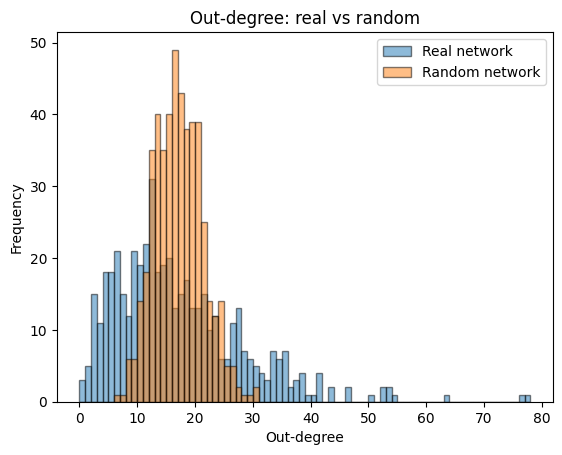

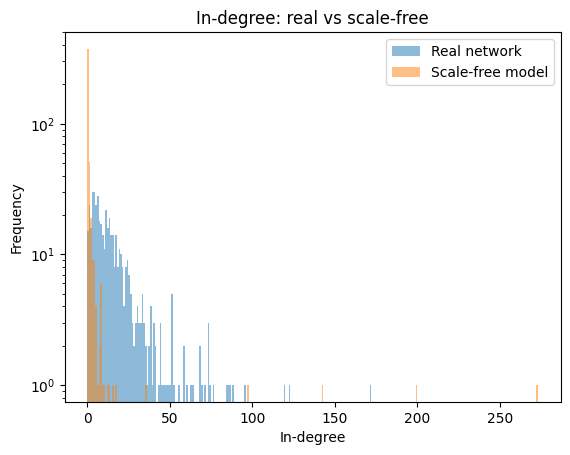

In [17]:
# Random network with same n and m
random_G = nx.gnm_random_graph(num_nodes, num_edges, directed=True)
rand_out_degrees = [d for _, d in random_G.out_degree()]

# Use same bins for both
bins_out = range(0, max(max(out_degrees), max(rand_out_degrees)) + 2)

plt.hist(out_degrees, bins=bins_out, alpha=0.5, label="Real network", edgecolor="black")
plt.hist(rand_out_degrees, bins=bins_out, alpha=0.5, label="Random network", edgecolor="black")
plt.xlabel("Out-degree")
plt.ylabel("Frequency")
plt.legend()
plt.title("Out-degree: real vs random")
plt.show()

# Scale-free comparison for in-degree
sf_G = nx.scale_free_graph(num_nodes, seed=2)
sf_in_degrees = [d for _, d in sf_G.in_degree()]

# Same bin edges for both
bins_in = range(0, max(max(in_degrees), max(sf_in_degrees)) + 2)

plt.hist(in_degrees, bins=bins_in, alpha=0.5, label="Real network")
plt.hist(sf_in_degrees, bins=bins_in, alpha=0.5, label="Scale-free model", log=True)
plt.xlabel("In-degree")
plt.ylabel("Frequency")
plt.legend()
plt.title("In-degree: real vs scale-free")
plt.show()


**Out-degree: Real vs Random**

The real network’s out-degree distribution (blue) is quite close to the random network (orange). Both show a peak around the middle range (10–20 out links per node) and decay relatively quickly. This makes sense as every performer’s Wikipedia page can only list a limited number of associated acts, so the out degree looks “random" rather than skewed.

**In-degree: Real vs Scale-free**

The real network’s in-degree distribution (blue) has a long heavy tail where a few performers receive very many incoming links, while most get very few. This in different with the scale-free model (orange), which concentrates almost everything at degree 0–20. The real data thus shows a lot slower "decay", but the same general trend applies. Only a few bands have very many links with many incoming links that reflects popularity and influence.

**Short summary**

* Out-degree behaves much like a random network.
* In-degree is heavy-tailed and better captured by scale-free dynamics as many bands reference a small set of famous acts.

>* Who are the top 5 most connected performers (Report results for in-degrees and out-degrees, that is, who has highest in-degree, who has highest out-degree)? Comment on your findings. Is this what you would have expected?

In [18]:
# Top 5 by in-degree
top_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 by in-degree:", top_in)

# Top 5 by out-degree
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 by out-degree:", top_out)

Top 5 by in-degree: [('The_Beatles', 171), ('The_Rolling_Stones', 122), ('Led_Zeppelin', 119), ('Bob_Dylan', 95), ('Queen_(band)', 88)]
Top 5 by out-degree: [('Alice_in_Chains', 77), ('Deep_Purple', 76), ('Black_Sabbath', 63), ("Guns_N'_Roses", 54), ('Bryan_Adams', 53)]


**In-degree:** The artists with the most in-degrees make sense, as they are very popular and influential bands, that might be referred to as inspiration on other Wikipedia pages, etc.<br> 
**Out-degree:** Top 5 out-degree is a little harder to comment on, but the artists in the list are also very popular, so it would make sense, that they have longer entries on Wikipedia, and therefore also link to several other pages. Although they're popular, however, you could argue, that they're not quite in the same league as the bands with the most in-degrees. Thus they might've worked with many artists, compared to those that are big enough to carry themselves completely, and maybe don't have time for as many collaborations.

> * What are the 10 pages with the longest wiki entries? (use the `length of content` attribute to figure this one out)?

In [19]:
# Sort nodes by content length attribute
longest_pages = sorted(
    G.nodes(data=True),
    key=lambda x: x[1].get("content_length", 0),
    reverse=True
)[:10]

print("Top 10 pages by content length:")
for node, attrs in longest_pages:
    print(node, ":", attrs["content_length"], "words")


Top 10 pages by content length:
Guns_N'_Roses : 60850 words
Coldplay : 47026 words
Queen_(band) : 46175 words
Marilyn_Manson_(band) : 46032 words
The_Rolling_Stones : 44022 words
U2 : 43048 words
Bob_Dylan : 42510 words
David_Bowie : 42415 words
Paul_McCartney : 42407 words
Elton_John : 41255 words


And the following exercise from **Part 3**
* *Let's build a simple visualization of the network*


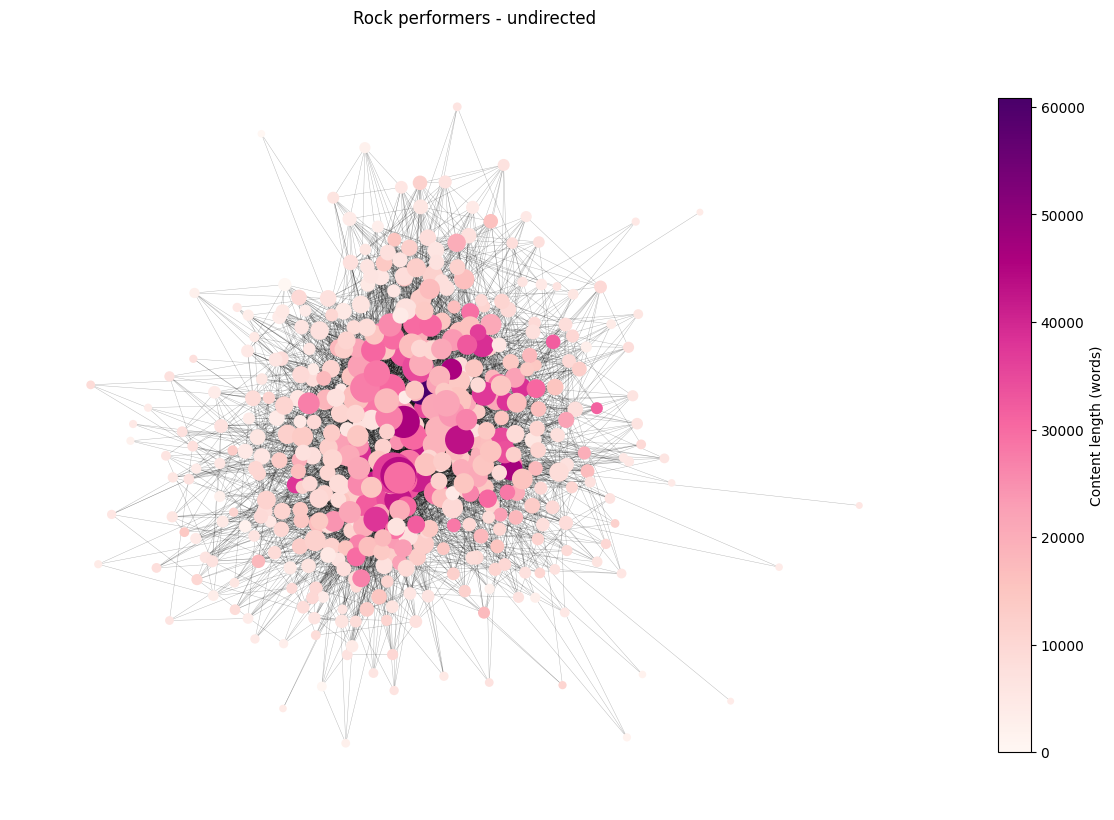

In [20]:
# Make an undirected copy
H_und = G.to_undirected()

# Pick a layout
pos = nx.spring_layout(H_und, seed=42)      

# Node sizes by degree
deg = dict(H_und.degree())
node_sizes = [20 + 5*deg[n] for n in H_und.nodes()]  

# Node colors by content length
node_colors = [H_und.nodes[n].get("content_length", 0) for n in H_und.nodes()]

# Draw
fig, ax = plt.subplots(figsize=(15, 10))
nodes = nx.draw_networkx_nodes(
    H_und, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="RdPu",         
    linewidths=0.0,
    ax=ax
)
nx.draw_networkx_edges(H_und, pos, width=0.3, alpha=0.3, ax=ax)

ax.set_title("Rock performers - undirected", pad=12)
ax.axis("off")

# Colorbar
cbar = plt.colorbar(nodes, ax=ax, shrink=0.85)
cbar.set_label("Content length (words)")

The visualization shows the formation of hubs, as described in the book, and that most nodes have more than one degree, indicating that several entries link to the same pages. This makes sense, as we are looking at rock artist, many of which have, inspirations, performances, labels, etc. in common, which coud be refered to in a Wikipedia article.

## Contributions
All three team members contributed across all sub parts of the project, but the main responsibles for different sections are as follows:
* 1.1 (WS Edition): Nikolai (s224171)
* 1.1 (BA Edition): Sofie (s224185)
* 1.2 (Network crawling): Mathias (s214422)
* 1.2 (In- and out-degree analysis): Mathias (s214422)
* 1.2 (Network comparisons and node highlights): Nikolai (s224171)
* 1.2 (Network visualization): Sofie (s224185)

All members have completed the weekly exercises needed for this project. The final result is a combination of different approaches, reflecting the work of individual efforts into the resulting outcome.